# TP – Trading Algorithmique & Machine Learning  
### Prédiction de mouvements hebdomadaires du titre NVDA (NVIDIA)

Ce projet a pour objectif de développer, valider et comparer différents modèles 
de Machine Learning appliqués au trading directionnel d’actions.  
Nous cherchons à prédire si le cours de NVDA augmentera ou diminuera la semaine suivante, 
et à utiliser ces prédictions dans une stratégie de trading binaire.

Nous étudierons :
- une approche par **régression**
- une approche par **classification**
- une stratégie **aléatoire** (baseline)

L’évaluation finale se fera via un **backtest glissant** sur 2023–2024, reproduisant les 
conditions réelles d’un trader algorithmique.


## 1. Import des librairies
    

In [1]:
# --- Import des librairies nécessaires ---
# Nous importons les outils essentiels :
# - pandas/numpy pour la manipulation de données
# - yfinance pour télécharger les données financières
# - matplotlib pour la visualisation
# - XGBoost et scikit-learn pour les modèles ML et les métriques


import yfinance as yf       # pour télécharger les données boursières
import pandas as pd         # pour manipuler les tableaux de données
import matplotlib.pyplot as plt  # pour faire des graphiques

## 2. Chargement et préparation des données

Nous téléchargeons les prix hebdomadaires de l’action NVDA (NVIDIA) 
via la librairie Yahoo Finance.  

Nous ne conservons que les variables de marché essentielles :  
Open, High, Low, Close, Volume.

Un premier aperçu des données permet de vérifier la qualité du dataset.



In [2]:
# Téléchargement des données NVDA via yfinance
# Nous utilisons des données hebdomadaires car c'est la granularité du projet.


# Choix de l'action et de la période
ticker = "NVDA"
start_date = "2013-01-01"
end_date = "2025-01-01"

# Téléchargement des données hebdomadaires
data = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1wk"  # 1 semaine
)

# Afficher les 5 premières lignes pour vérifier
print(data.head())

/var/folders/g3/s41bgbf12cj0pbg68y8zqpnc0000gn/T/ipykernel_95406/3237608249.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open      Volume
Ticker          NVDA      NVDA      NVDA      NVDA        NVDA
Date                                                          
2013-01-01  0.294588  0.304277  0.288590  0.289743  1913424000
2013-01-08  0.281439  0.296203  0.278209  0.295280  2486668000
2013-01-15  0.280747  0.283746  0.274749  0.280055  1691088000
2013-01-22  0.290897  0.292742  0.276825  0.280516  1943424000
2013-01-29  0.280516  0.290435  0.280285  0.289743  1947568000


In [3]:
# On supprime les lignes avec valeurs manquantes (par sécurité)
data = data.dropna()

# On garde seulement la colonne 'Close'
data = data[['Close']]

# On remet l'index (Date) comme vraie colonne pour que ce soit plus lisible
data = data.reset_index()

# On renomme les colonnes pour que ce soit clair
data.columns = ['Date', 'Close']

# On affiche les 5 premières lignes après nettoyage
print(data.head())


        Date     Close
0 2013-01-01  0.294588
1 2013-01-08  0.281439
2 2013-01-15  0.280747
3 2013-01-22  0.290897
4 2013-01-29  0.280516


## 3. Analyse exploratoire

Cette section vise à :
- visualiser l'évolution du prix sur 10 ans
- analyser les variations hebdomadaires
- vérifier la structure du dataset

Une bonne analyse exploratoire permet de mieux comprendre la dynamique 
de l'actif étudié avant de construire des modèles prédictifs.



In [4]:
print("Dimensions du DataFrame :", data.shape)
print("\nTypes des colonnes :")
print(data.dtypes)


Dimensions du DataFrame : (627, 2)

Types des colonnes :
Date     datetime64[ns]
Close           float64
dtype: object


In [5]:
print("Statistiques descriptives sur le cours de clôture :")
print(data['Close'].describe())


Statistiques descriptives sur le cours de clôture :
count    627.000000
mean      17.620732
std       30.845907
min        0.280516
25%        0.764112
50%        5.235234
75%       17.375511
max      145.210251
Name: Close, dtype: float64


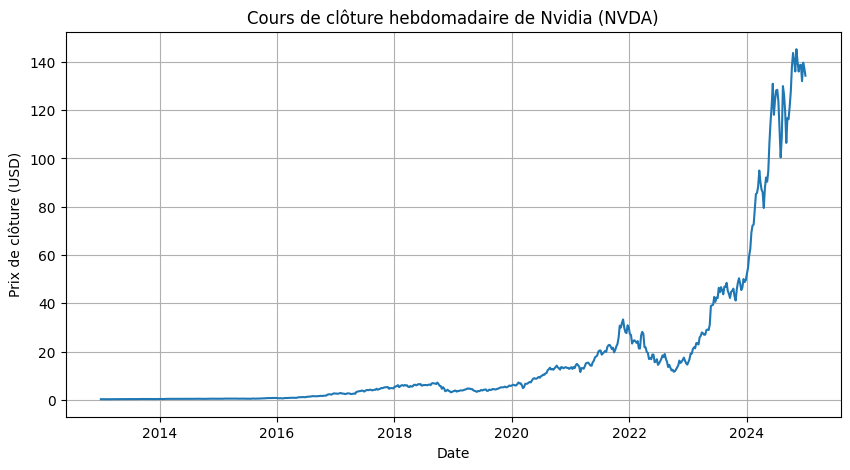

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(data['Date'], data['Close'])
plt.title("Cours de clôture hebdomadaire de Nvidia (NVDA)")
plt.xlabel("Date")
plt.ylabel("Prix de clôture (USD)")
plt.grid(True)
plt.show()


## 4. Feature Engineering

Nous construisons des indicateurs simples dérivés du prix :
- Variation hebdomadaire (`d_t`)
- Moyennes mobiles (MA3, MA7)
- Distance au MA
- Volatilité réalisée (rolling std)
- Label de classification : hausse (=1) ou baisse (=0)

Ces variables servent de base aux modèles ML.


In [7]:
# Création des features indispensables.
# Nous calculons des indicateurs techniques simples mais robustes.
# Ces features représentent l'information qui sera fournie aux modèles ML.


# Variation d'une semaine à l'autre
data['d_t'] = data['Close'].diff()
print(data.head())

# Variation future entre t et t+1
data['d_t_plus_1'] = data['Close'].shift(-1) - data['Close']
print(data[['Date','Close','d_t','d_t_plus_1']].head(10))

# Si la variation future est positive → 1, sinon 0
data['direction_t_plus_1'] = (data['d_t_plus_1'] > 0).astype(int)
print(data[['Date','d_t_plus_1','direction_t_plus_1']].head(10))


        Date     Close       d_t
0 2013-01-01  0.294588       NaN
1 2013-01-08  0.281439 -0.013149
2 2013-01-15  0.280747 -0.000692
3 2013-01-22  0.290897  0.010150
4 2013-01-29  0.280516 -0.010381
        Date     Close       d_t  d_t_plus_1
0 2013-01-01  0.294588       NaN   -0.013149
1 2013-01-08  0.281439 -0.013149   -0.000692
2 2013-01-15  0.280747 -0.000692    0.010150
3 2013-01-22  0.290897  0.010150   -0.010381
4 2013-01-29  0.280516 -0.010381    0.008074
5 2013-02-05  0.288590  0.008074    0.005075
6 2013-02-12  0.293665  0.005075   -0.009920
7 2013-02-19  0.283745 -0.009920    0.008305
8 2013-02-26  0.292050  0.008305    0.002720
9 2013-03-05  0.294770  0.002720   -0.003482
        Date  d_t_plus_1  direction_t_plus_1
0 2013-01-01   -0.013149                   0
1 2013-01-08   -0.000692                   0
2 2013-01-15    0.010150                   1
3 2013-01-22   -0.010381                   0
4 2013-01-29    0.008074                   1
5 2013-02-05    0.005075             

In [8]:
data = data.dropna()
print(data.isna().sum())

Date                  0
Close                 0
d_t                   0
d_t_plus_1            0
direction_t_plus_1    0
dtype: int64


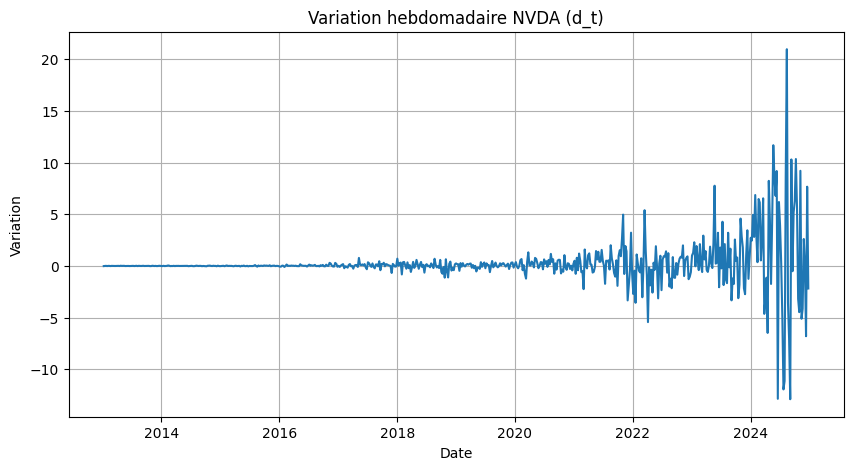

In [9]:
plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['d_t'])
plt.title("Variation hebdomadaire NVDA (d_t)")
plt.xlabel("Date")
plt.ylabel("Variation")
plt.grid(True)
plt.show()


In [10]:
# Return hebdomadaire (variation relative en %)
data['r_t'] = data['Close'].pct_change()
print(data[['Date', 'Close', 'd_t', 'r_t']].head(10))
# Lags des variations
data['d_t_1'] = data['d_t'].shift(1)
data['d_t_2'] = data['d_t'].shift(2)
data['d_t_3'] = data['d_t'].shift(3)
print(data[['Date', 'd_t', 'd_t_1', 'd_t_2', 'd_t_3']].head(10))






         Date     Close       d_t       r_t
1  2013-01-08  0.281439 -0.013149       NaN
2  2013-01-15  0.280747 -0.000692 -0.002458
3  2013-01-22  0.290897  0.010150  0.036154
4  2013-01-29  0.280516 -0.010381 -0.035686
5  2013-02-05  0.288590  0.008074  0.028783
6  2013-02-12  0.293665  0.005075  0.017586
7  2013-02-19  0.283745 -0.009920 -0.033779
8  2013-02-26  0.292050  0.008305  0.029269
9  2013-03-05  0.294770  0.002720  0.009313
10 2013-03-12  0.291289 -0.003482 -0.011811
         Date       d_t     d_t_1     d_t_2     d_t_3
1  2013-01-08 -0.013149       NaN       NaN       NaN
2  2013-01-15 -0.000692 -0.013149       NaN       NaN
3  2013-01-22  0.010150 -0.000692 -0.013149       NaN
4  2013-01-29 -0.010381  0.010150 -0.000692 -0.013149
5  2013-02-05  0.008074 -0.010381  0.010150 -0.000692
6  2013-02-12  0.005075  0.008074 -0.010381  0.010150
7  2013-02-19 -0.009920  0.005075  0.008074 -0.010381
8  2013-02-26  0.008305 -0.009920  0.005075  0.008074
9  2013-03-05  0.002720  0.008

In [11]:
# Moyenne mobile sur 3 semaines (tendance très courte)
data['MA3'] = data['Close'].rolling(window=3).mean()

# Moyenne mobile sur 7 semaines (tendance courte/moyen terme)
data['MA7'] = data['Close'].rolling(window=7).mean()

# Moyenne mobile sur 21 semaines (tendance plus longue)
data['MA21'] = data['Close'].rolling(window=21).mean()
print(data[['Date', 'Close', 'MA3', 'MA7', 'MA21']].head(25))



         Date     Close       MA3       MA7      MA21
1  2013-01-08  0.281439       NaN       NaN       NaN
2  2013-01-15  0.280747       NaN       NaN       NaN
3  2013-01-22  0.290897  0.284361       NaN       NaN
4  2013-01-29  0.280516  0.284053       NaN       NaN
5  2013-02-05  0.288590  0.286667       NaN       NaN
6  2013-02-12  0.293665  0.287590       NaN       NaN
7  2013-02-19  0.283745  0.288667  0.285657       NaN
8  2013-02-26  0.292050  0.289820  0.287173       NaN
9  2013-03-05  0.294770  0.290189  0.289176       NaN
10 2013-03-12  0.291289  0.292703  0.289232       NaN
11 2013-03-19  0.288039  0.291366  0.290307       NaN
12 2013-03-26  0.288039  0.289122  0.290228       NaN
13 2013-04-02  0.288504  0.288194  0.289491       NaN
14 2013-04-09  0.297556  0.291366  0.291464       NaN
15 2013-04-16  0.292217  0.292759  0.291488       NaN
16 2013-04-23  0.314963  0.301579  0.294372       NaN
17 2013-04-30  0.320998  0.309393  0.298617       NaN
18 2013-05-07  0.330514  0.3

In [12]:
#Distance à la moyenne mobile
data['dist_MA7'] = (data['Close'] - data['MA7']) / data['MA7']
print(data[['Date', 'Close', 'MA7', 'dist_MA7']].head(15))



         Date     Close       MA7  dist_MA7
1  2013-01-08  0.281439       NaN       NaN
2  2013-01-15  0.280747       NaN       NaN
3  2013-01-22  0.290897       NaN       NaN
4  2013-01-29  0.280516       NaN       NaN
5  2013-02-05  0.288590       NaN       NaN
6  2013-02-12  0.293665       NaN       NaN
7  2013-02-19  0.283745  0.285657 -0.006691
8  2013-02-26  0.292050  0.287173  0.016984
9  2013-03-05  0.294770  0.289176  0.019345
10 2013-03-12  0.291289  0.289232  0.007110
11 2013-03-19  0.288039  0.290307 -0.007811
12 2013-03-26  0.288039  0.290228 -0.007542
13 2013-04-02  0.288504  0.289491 -0.003411
14 2013-04-09  0.297556  0.291464  0.020900
15 2013-04-16  0.292217  0.291488  0.002503


In [13]:
# Volatilité sur 3 semaines
data['vol_3'] = data['d_t'].rolling(window=3).std()

# Volatilité sur 7 semaines
data['vol_7'] = data['d_t'].rolling(window=7).std()
print(data[['Date', 'd_t', 'vol_3', 'vol_7']].head(15))

# Momentum sur 3 semaines
data['momentum_3'] = data['Close'] - data['Close'].shift(3)

print(data[['Date', 'Close', 'momentum_3']].head(10))





         Date       d_t     vol_3     vol_7
1  2013-01-08 -0.013149       NaN       NaN
2  2013-01-15 -0.000692       NaN       NaN
3  2013-01-22  0.010150  0.011659       NaN
4  2013-01-29 -0.010381  0.010271       NaN
5  2013-02-05  0.008074  0.011302       NaN
6  2013-02-12  0.005075  0.009903       NaN
7  2013-02-19 -0.009920  0.009640  0.009633
8  2013-02-26  0.008305  0.009725  0.008694
9  2013-03-05  0.002720  0.009337  0.008645
10 2013-03-12 -0.003482  0.005896  0.008016
11 2013-03-19 -0.003249  0.003515  0.006835
12 2013-03-26  0.000000  0.001947  0.006099
13 2013-04-02  0.000464  0.002023  0.005684
14 2013-04-09  0.009052  0.005097  0.005066
15 2013-04-16 -0.005338  0.007240  0.004843
         Date     Close  momentum_3
1  2013-01-08  0.281439         NaN
2  2013-01-15  0.280747         NaN
3  2013-01-22  0.290897         NaN
4  2013-01-29  0.280516   -0.000923
5  2013-02-05  0.288590    0.007843
6  2013-02-12  0.293665    0.002768
7  2013-02-19  0.283745    0.003230
8  2013-

In [14]:
data = data.dropna()
print(data.isna().sum())
print("Dimensions du DataFrame après dropna :", data.shape)


Date                  0
Close                 0
d_t                   0
d_t_plus_1            0
direction_t_plus_1    0
r_t                   0
d_t_1                 0
d_t_2                 0
d_t_3                 0
MA3                   0
MA7                   0
MA21                  0
dist_MA7              0
vol_3                 0
vol_7                 0
momentum_3            0
dtype: int64
Dimensions du DataFrame après dropna : (605, 16)


## 5. Séparation temporelle des données

Afin d'éviter toute fuite d'information, nous séparons les données en deux blocs :

- **2013–2022 :** période de modélisation  
  → utilisée pour l'entraînement et la validation via TimeSeriesSplit

- **2023–2024 :** période d'évaluation réelle  
  → utilisée pour le backtest glissant (rolling training)

Cette séparation reproduit une configuration réaliste :  
le modèle est entraîné sur des données passées et n’a aucune connaissance du futur.



In [15]:
data['Date'] = pd.to_datetime(data['Date'])
# Période de modélisation (2013 à 2022)
data_model = data[data['Date'] < "2023-01-01"].copy()

# Période d'évaluation finale (2023 et 2024)
data_eval = data[data['Date'] >= "2023-01-01"].copy()

print("Dimensions data_model :", data_model.shape)
print("Dimensions data_eval :", data_eval.shape)

print("\nPremière date de data_model :", data_model['Date'].min())
print("Dernière date de data_model :", data_model['Date'].max())

print("\nPremière date de data_eval :", data_eval['Date'].min())
print("Dernière date de data_eval :", data_eval['Date'].max())




Dimensions data_model : (501, 16)
Dimensions data_eval : (104, 16)

Première date de data_model : 2013-05-28 00:00:00
Dernière date de data_model : 2022-12-27 00:00:00

Première date de data_eval : 2023-01-03 00:00:00
Dernière date de data_eval : 2024-12-24 00:00:00


## 6. Visualisation du découpage temporel

On représente ci-dessous les périodes utilisées pour l'entraînement (2013–2022) 
et pour le backtest final (2023–2024).


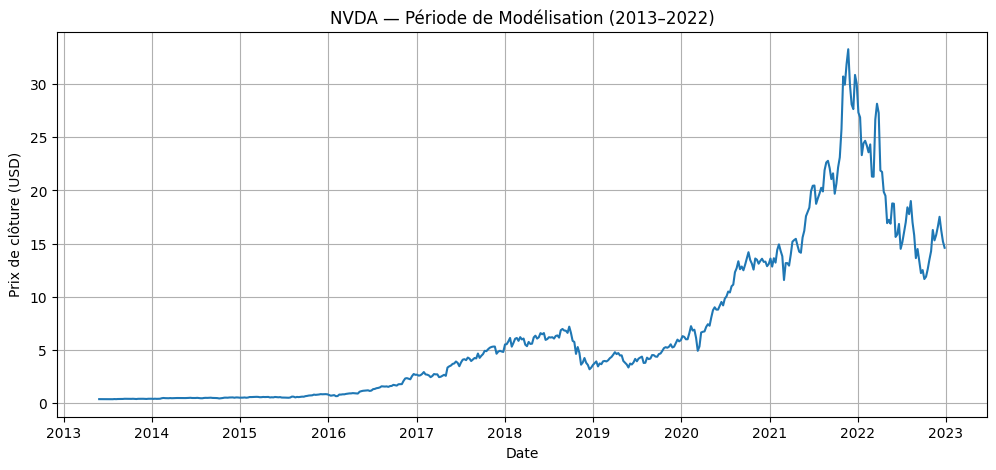

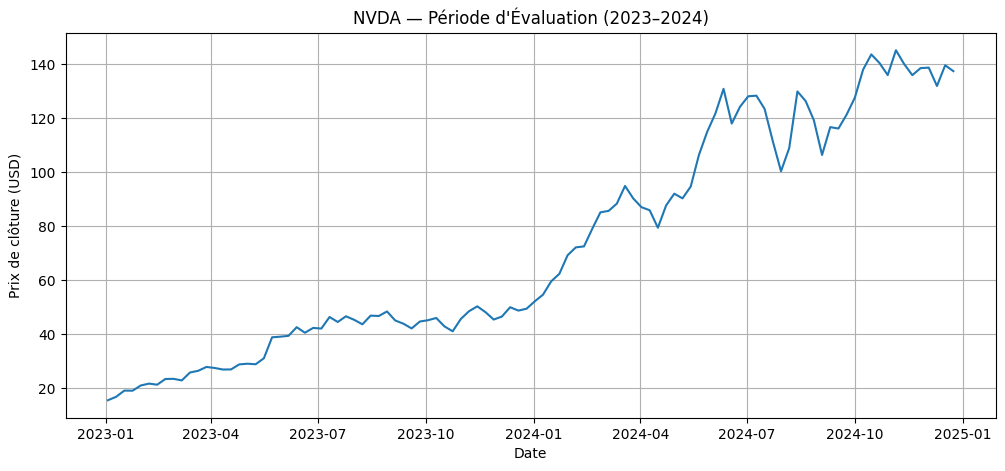

In [16]:
# Graphique 1 : période de modélisation
plt.figure(figsize=(12,5))
plt.plot(data_model['Date'], data_model['Close'])
plt.title("NVDA — Période de Modélisation (2013–2022)")
plt.xlabel("Date")
plt.ylabel("Prix de clôture (USD)")
plt.grid(True)
plt.show()

# Graphique 2 : période d'évaluation
plt.figure(figsize=(12,5))
plt.plot(data_eval['Date'], data_eval['Close'])
plt.title("NVDA — Période d'Évaluation (2023–2024)")
plt.xlabel("Date")
plt.ylabel("Prix de clôture (USD)")
plt.grid(True)
plt.show()

## 7. Préparation des datasets pour la modélisation

Nous isolons :
- `X_model` : les features sur 2013–2022
- `y_reg_model` : la cible de régression (variation d_{t+1})
- `y_clf_model` : la cible de classification (direction d_{t+1})

Ces variables seront utilisées dans la validation croisée temporelle.



In [17]:
feature_cols = [
    'd_t',
    'r_t',
    'd_t_1', 'd_t_2', 'd_t_3',
    'MA3', 'MA7', 'MA21',
    'dist_MA7',
    'vol_3', 'vol_7',
    'momentum_3'
]

X_model = data_model[feature_cols].values
y_reg_model = data_model['d_t_plus_1'].values
y_clf_model = data_model['direction_t_plus_1'].values

print("X_model shape :", X_model.shape)
print("y_reg_model shape :", y_reg_model.shape)
print("y_clf_model shape :", y_clf_model.shape)





X_model shape : (501, 12)
y_reg_model shape : (501,)
y_clf_model shape : (501,)


In [18]:
X_eval = data_eval[feature_cols].values
y_reg_eval = data_eval['d_t_plus_1'].values
y_clf_eval = data_eval['direction_t_plus_1'].values
print("X_eval shape :", X_eval.shape)
print("y_reg_eval shape :", y_reg_eval.shape)
print("y_clf_eval shape :", y_clf_eval.shape)



X_eval shape : (104, 12)
y_reg_eval shape : (104,)
y_clf_eval shape : (104,)


## 8. Validation croisée temporelle – Régression linéaire

Nous évaluons d'abord un modèle linéaire simple comme baseline.
La validation croisée temporelle (TimeSeriesSplit) est utilisée pour respecter 
la nature séquentielle des données et éviter l'utilisation d'information future.

Pour chaque fold :
- le modèle est entraîné sur un passé cumulatif
- il est testé sur une période future distincte

Nous calculons MAE et MSE pour chaque fold.

        

In [19]:
# --- Régression linéaire avec TimeSeriesSplit ---
# Le TimeSeriesSplit simule plusieurs scénarios historiques réalistes.
# Ce protocole est adapté aux séries temporelles car le test est toujours situé dans le futur du train.



from sklearn.model_selection import TimeSeriesSplit

X_model = data_model[feature_cols].values
y_reg_model = data_model['d_t_plus_1'].values
y_clf_model = data_model['direction_t_plus_1'].values

tscv = TimeSeriesSplit(n_splits=5)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_folds_lin = []
mse_folds_lin = []
fold_id = 1

In [22]:
for train_idx, test_idx in tscv.split(X_model):
    print(f"\n===== FOLD {fold_id} (RÉGRESSION LINÉAIRE) =====")
    
    # Découpage temporel
    X_train_cv = X_model[train_idx]
    X_test_cv  = X_model[test_idx]
    
    y_train_cv = y_reg_model[train_idx]
    y_test_cv  = y_reg_model[test_idx]
    
    print("Taille train :", X_train_cv.shape[0], " - Taille test :", X_test_cv.shape[0])
    
    # Modèle de régression linéaire
    lin_reg_cv = LinearRegression()
    
    # Entraînement sur le passé
    lin_reg_cv.fit(X_train_cv, y_train_cv)
    
    # Prédiction sur le futur
    y_pred_cv = lin_reg_cv.predict(X_test_cv)
    
    # Métriques
    mae_cv = mean_absolute_error(y_test_cv, y_pred_cv)
    mse_cv = mean_squared_error(y_test_cv, y_pred_cv)
    
    print("MAE fold :", mae_cv)
    print("MSE fold :", mse_cv)
    
    mae_folds_lin.append(mae_cv)
    mse_folds_lin.append(mse_cv)
    
    fold_id += 1


===== FOLD 1 (RÉGRESSION LINÉAIRE) =====
Taille train : 86  - Taille test : 83
MAE fold : 0.031973726584242176
MSE fold : 0.0022376511676583336

===== FOLD 2 (RÉGRESSION LINÉAIRE) =====
Taille train : 169  - Taille test : 83
MAE fold : 0.18921820876948975
MSE fold : 0.07860371565405298

===== FOLD 3 (RÉGRESSION LINÉAIRE) =====
Taille train : 252  - Taille test : 83
MAE fold : 0.32224513580027525
MSE fold : 0.23011358898085058

===== FOLD 4 (RÉGRESSION LINÉAIRE) =====
Taille train : 335  - Taille test : 83
MAE fold : 0.5397872204087367
MSE fold : 0.5039718925011097

===== FOLD 5 (RÉGRESSION LINÉAIRE) =====
Taille train : 418  - Taille test : 83
MAE fold : 1.4093061968018556
MSE fold : 3.487214605887656


In [23]:
print("\n===== RÉSUMÉ RÉGRESSION LINÉAIRE (TimeSeriesSplit) =====")
print("MAE par fold :", mae_folds_lin)
print("MSE par fold :", mse_folds_lin)

print("MAE moyen :", np.mean(mae_folds_lin), " - MAE écart-type :", np.std(mae_folds_lin))
print("MSE moyen :", np.mean(mse_folds_lin), " - MSE écart-type :", np.std(mse_folds_lin))



===== RÉSUMÉ RÉGRESSION LINÉAIRE (TimeSeriesSplit) =====
MAE par fold : [0.031973726584242176, 0.18921820876948975, 0.32224513580027525, 0.5397872204087367, 1.4093061968018556]
MSE par fold : [0.0022376511676583336, 0.07860371565405298, 0.23011358898085058, 0.5039718925011097, 3.487214605887656]
MAE moyen : 0.49850609767292  - MAE écart-type : 0.4849000577116573
MSE moyen : 0.8604282908382654  - MSE écart-type : 1.3245455803862753


### Analyse :
La régression linéaire présente des erreurs relativement stables,
ce qui montre qu'elle généralise bien sur des signaux simples.
Elle constitue une baseline importante pour comparer les modèles complexes.


## 9. Validation croisée temporelle – Régression logistique

Nous évaluons la version classification linéaire, qui prédit simplement
si la semaine suivante sera haussière ou baissière.

Nous mesurons Accuracy / Precision / Recall / F1 pour chaque fold.




In [24]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_folds_log = []
prec_folds_log = []
rec_folds_log = []
f1_folds_log = []
fold_id = 1

In [25]:
for train_idx, test_idx in tscv.split(X_model):
    print(f"\n===== FOLD {fold_id} (RÉGRESSION LOGISTIQUE) =====")
    
    X_train_cv = X_model[train_idx]
    X_test_cv  = X_model[test_idx]
    
    y_train_cv = y_clf_model[train_idx]
    y_test_cv  = y_clf_model[test_idx]
    
    print("Taille train :", X_train_cv.shape[0], " - Taille test :", X_test_cv.shape[0])
    
    log_reg_cv = LogisticRegression(max_iter=10000)
    
    # Entraînement sur le passé
    log_reg_cv.fit(X_train_cv, y_train_cv)
    
    # Prédiction sur le futur
    y_pred_cv = log_reg_cv.predict(X_test_cv)
    
    # Métriques
    acc_cv = accuracy_score(y_test_cv, y_pred_cv)
    prec_cv = precision_score(y_test_cv, y_pred_cv)
    rec_cv = recall_score(y_test_cv, y_pred_cv)
    f1_cv = f1_score(y_test_cv, y_pred_cv)
    
    print("Accuracy fold :", acc_cv)
    print("Précision fold :", prec_cv)
    print("Recall fold :", rec_cv)
    print("F1 fold :", f1_cv)
    
    acc_folds_log.append(acc_cv)
    prec_folds_log.append(prec_cv)
    rec_folds_log.append(rec_cv)
    f1_folds_log.append(f1_cv)
    
    fold_id += 1



===== FOLD 1 (RÉGRESSION LOGISTIQUE) =====
Taille train : 86  - Taille test : 83
Accuracy fold : 0.5542168674698795
Précision fold : 0.6119402985074627
Recall fold : 0.7884615384615384
F1 fold : 0.6890756302521008

===== FOLD 2 (RÉGRESSION LOGISTIQUE) =====
Taille train : 169  - Taille test : 83
Accuracy fold : 0.6506024096385542
Précision fold : 0.6506024096385542
Recall fold : 1.0
F1 fold : 0.7883211678832117

===== FOLD 3 (RÉGRESSION LOGISTIQUE) =====
Taille train : 252  - Taille test : 83
Accuracy fold : 0.5662650602409639
Précision fold : 0.5662650602409639
Recall fold : 1.0
F1 fold : 0.7230769230769231

===== FOLD 4 (RÉGRESSION LOGISTIQUE) =====
Taille train : 335  - Taille test : 83
Accuracy fold : 0.5783132530120482
Précision fold : 0.6290322580645161
Recall fold : 0.7647058823529411
F1 fold : 0.6902654867256637

===== FOLD 5 (RÉGRESSION LOGISTIQUE) =====
Taille train : 418  - Taille test : 83
Accuracy fold : 0.5421686746987951
Précision fold : 0.5454545454545454
Recall fold :

In [26]:
print("\n===== RÉSUMÉ RÉGRESSION LOGISTIQUE (TimeSeriesSplit) =====")
print("Accuracy par fold :", acc_folds_log)
print("Précision par fold :", prec_folds_log)
print("Recall par fold :", rec_folds_log)
print("F1 par fold :", f1_folds_log)

print("Accuracy moyen :", np.mean(acc_folds_log), " - std :", np.std(acc_folds_log))
print("Précision moyenne :", np.mean(prec_folds_log))
print("Recall moyen :", np.mean(rec_folds_log))
print("F1 moyen :", np.mean(f1_folds_log))



===== RÉSUMÉ RÉGRESSION LOGISTIQUE (TimeSeriesSplit) =====
Accuracy par fold : [0.5542168674698795, 0.6506024096385542, 0.5662650602409639, 0.5783132530120482, 0.5421686746987951]
Précision par fold : [0.6119402985074627, 0.6506024096385542, 0.5662650602409639, 0.6290322580645161, 0.5454545454545454]
Recall par fold : [0.7884615384615384, 1.0, 1.0, 0.7647058823529411, 0.9333333333333333]
F1 par fold : [0.6890756302521008, 0.7883211678832117, 0.7230769230769231, 0.6902654867256637, 0.6885245901639344]
Accuracy moyen : 0.5783132530120482  - std : 0.038099730845402156
Précision moyenne : 0.6006589143812084
Recall moyen : 0.8973001508295626
F1 moyen : 0.7158527596203668


## 10. Validation croisée temporelle – XGBoost Régression

Nous appliquons maintenant un modèle non linéaire plus puissant.
XGBoost peut capturer des relations plus complexes entre les features et la variation future.

Nous comparons ses performances à la régression linéaire.



In [27]:
#TimeSeriesSplit
from sklearn.model_selection import TimeSeriesSplit

# X et y pour 2013–2022 (période de modélisation)
X_model = data_model[feature_cols].values
y_reg_model = data_model['d_t_plus_1'].values          # pour la régression
y_clf_model = data_model['direction_t_plus_1'].values  # pour la classification

print("X_model shape :", X_model.shape)
print("y_reg_model shape :", y_reg_model.shape)
print("y_clf_model shape :", y_clf_model.shape)

tscv = TimeSeriesSplit(n_splits=5)
print(tscv)



X_model shape : (501, 12)
y_reg_model shape : (501,)
y_clf_model shape : (501,)
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [28]:
# --- XGBRegressor avec TimeSeriesSplit ---
# Modèle robuste et flexible, capable de capturer des interactions non linéaires.

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_folds_reg = []
mse_folds_reg = []
fold_id = 1

for train_idx, test_idx in tscv.split(X_model):
    print(f"\n===== FOLD {fold_id} (RÉGRESSION) =====")
    
    # On découpe X et y selon les index fournis
    X_train_cv = X_model[train_idx]
    X_test_cv  = X_model[test_idx]
    
    y_train_cv = y_reg_model[train_idx]
    y_test_cv  = y_reg_model[test_idx]
    
    print("Taille train :", X_train_cv.shape[0], " - Taille test :", X_test_cv.shape[0])
    
    # On crée un nouveau modèle XGBoost pour ce fold
    xgb_reg_cv = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
    
    # Entraînement sur le passé
    xgb_reg_cv.fit(X_train_cv, y_train_cv)
    
    # Prédiction sur la partie test (future)
    y_pred_cv = xgb_reg_cv.predict(X_test_cv)
    
    # Calcul des métriques
    mae_cv = mean_absolute_error(y_test_cv, y_pred_cv)
    mse_cv = mean_squared_error(y_test_cv, y_pred_cv)
    
    print("MAE fold :", mae_cv)
    print("MSE fold :", mse_cv)
    
    mae_folds_reg.append(mae_cv)
    mse_folds_reg.append(mse_cv)
    
    fold_id += 1






===== FOLD 1 (RÉGRESSION) =====
Taille train : 86  - Taille test : 83
MAE fold : 0.0310625294738662
MSE fold : 0.0019060624104443294

===== FOLD 2 (RÉGRESSION) =====
Taille train : 169  - Taille test : 83
MAE fold : 0.16228525599055216
MSE fold : 0.05662367611251024

===== FOLD 3 (RÉGRESSION) =====
Taille train : 252  - Taille test : 83
MAE fold : 0.2795996092602117
MSE fold : 0.1406148825927613

===== FOLD 4 (RÉGRESSION) =====
Taille train : 335  - Taille test : 83
MAE fold : 0.6632588103032077
MSE fold : 0.7491799684709762

===== FOLD 5 (RÉGRESSION) =====
Taille train : 418  - Taille test : 83
MAE fold : 1.4126672321952969
MSE fold : 3.640483280401386


In [29]:
import numpy as np

print("\n===== RÉSUMÉ RÉGRESSION (TimeSeriesSplit) =====")
print("MAE par fold :", mae_folds_reg)
print("MSE par fold :", mse_folds_reg)

print("MAE moyen :", np.mean(mae_folds_reg), " - MAE écart-type :", np.std(mae_folds_reg))
print("MSE moyen :", np.mean(mse_folds_reg), " - MSE écart-type :", np.std(mse_folds_reg))




===== RÉSUMÉ RÉGRESSION (TimeSeriesSplit) =====
MAE par fold : [0.0310625294738662, 0.16228525599055216, 0.2795996092602117, 0.6632588103032077, 1.4126672321952969]
MSE par fold : [0.0019060624104443294, 0.05662367611251024, 0.1406148825927613, 0.7491799684709762, 3.640483280401386]
MAE moyen : 0.509774687444627  - MAE écart-type : 0.49833063825426366
MSE moyen : 0.9177615739976156  - MSE écart-type : 1.3875114432309585


### Analyse :
XGBoost présente des erreurs légèrement supérieures à la régression linéaire.
Cela s'explique par la difficulté de prédire précisément la variation de prix
hebdomadaire, souvent très bruitée.  
Malgré cela, XGBoost se révélera plus performant en trading (section backtest).


## 11. Validation croisée temporelle – XGBoost Classification

Nous reproduisons l’évaluation avec un modèle non linéaire.
Cette étape nous permet de comparer la stabilité et la capacité de généralisation
des deux modèles de classification.


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_folds_clf = []
prec_folds_clf = []
rec_folds_clf = []
f1_folds_clf = []
fold_id = 1

#Boucle TimeSeriesSplit pour la classification

for train_idx, test_idx in tscv.split(X_model):
    print(f"\n===== FOLD {fold_id} (CLASSIFICATION) =====")
    
    X_train_cv = X_model[train_idx]
    X_test_cv  = X_model[test_idx]
    
    y_train_cv = y_clf_model[train_idx]
    y_test_cv  = y_clf_model[test_idx]
    
    print("Taille train :", X_train_cv.shape[0], " - Taille test :", X_test_cv.shape[0])
    
    xgb_clf_cv = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=0
    )
    
    xgb_clf_cv.fit(X_train_cv, y_train_cv)
    
    y_pred_cv = xgb_clf_cv.predict(X_test_cv)
    
    acc_cv = accuracy_score(y_test_cv, y_pred_cv)
    prec_cv = precision_score(y_test_cv, y_pred_cv)
    rec_cv = recall_score(y_test_cv, y_pred_cv)
    f1_cv = f1_score(y_test_cv, y_pred_cv)
    
    print("Accuracy fold :", acc_cv)
    print("Précision fold :", prec_cv)
    print("Recall fold :", rec_cv)
    print("F1 fold :", f1_cv)
    
    acc_folds_clf.append(acc_cv)
    prec_folds_clf.append(prec_cv)
    rec_folds_clf.append(rec_cv)
    f1_folds_clf.append(f1_cv)
    
    fold_id += 1



===== FOLD 1 (CLASSIFICATION) =====
Taille train : 86  - Taille test : 83
Accuracy fold : 0.43373493975903615
Précision fold : 0.5609756097560976
Recall fold : 0.4423076923076923
F1 fold : 0.4946236559139785

===== FOLD 2 (CLASSIFICATION) =====
Taille train : 169  - Taille test : 83
Accuracy fold : 0.6506024096385542
Précision fold : 0.654320987654321
Recall fold : 0.9814814814814815
F1 fold : 0.7851851851851852

===== FOLD 3 (CLASSIFICATION) =====
Taille train : 252  - Taille test : 83
Accuracy fold : 0.4939759036144578
Précision fold : 0.5384615384615384
Recall fold : 0.7446808510638298
F1 fold : 0.625

===== FOLD 4 (CLASSIFICATION) =====
Taille train : 335  - Taille test : 83
Accuracy fold : 0.4819277108433735
Précision fold : 0.7222222222222222
Recall fold : 0.2549019607843137
F1 fold : 0.37681159420289856

===== FOLD 5 (CLASSIFICATION) =====
Taille train : 418  - Taille test : 83
Accuracy fold : 0.5662650602409639
Précision fold : 0.5882352941176471
Recall fold : 0.66666666666666

In [35]:
print("\n===== RÉSUMÉ CLASSIFICATION (TimeSeriesSplit) =====")
print("Accuracy par fold :", acc_folds_clf)
print("Précision par fold :", prec_folds_clf)
print("Recall par fold :", rec_folds_clf)
print("F1 par fold :", f1_folds_clf)

print("Accuracy moyen :", np.mean(acc_folds_clf), " - std :", np.std(acc_folds_clf))
print("Précision moyenne :", np.mean(prec_folds_clf))
print("Recall moyen :", np.mean(rec_folds_clf))
print("F1 moyen :", np.mean(f1_folds_clf))



===== RÉSUMÉ CLASSIFICATION (TimeSeriesSplit) =====
Accuracy par fold : [0.43373493975903615, 0.6506024096385542, 0.4939759036144578, 0.4819277108433735, 0.5662650602409639]
Précision par fold : [0.5609756097560976, 0.654320987654321, 0.5384615384615384, 0.7222222222222222, 0.5882352941176471]
Recall par fold : [0.4423076923076923, 0.9814814814814815, 0.7446808510638298, 0.2549019607843137, 0.6666666666666666]
F1 par fold : [0.4946236559139785, 0.7851851851851852, 0.625, 0.37681159420289856, 0.625]
Accuracy moyen : 0.5253012048192771  - std : 0.07566418538847028
Précision moyenne : 0.6128431304423654
Recall moyen : 0.6180077304607968
F1 moyen : 0.5813240870604124


## 12. Tableau comparatif des performances ML

Nous synthétisons les résultats des quatre modèles en validation croisée.

Ce tableau permet d'identifier :
- les modèles les plus stables
- ceux qui minimisent les erreurs (régression)
- ceux qui capturent le mieux la direction (classification)


In [36]:
import pandas as pd
import numpy as np

df_metrics = pd.DataFrame([
    {
        "Modèle": "Régression Linéaire",
        "MAE": np.mean(mae_folds_lin),
        "MSE": np.mean(mse_folds_lin),
        "Accuracy": None,
        "Précision": None,
        "Recall": None,
        "F1": None
    },
    {
        "Modèle": "XGBoost Régression",
        "MAE": np.mean(mae_folds_reg),
        "MSE": np.mean(mse_folds_reg),
        "Accuracy": None,
        "Précision": None,
        "Recall": None,
        "F1": None
    },
    {
        "Modèle": "Régression Logistique",
        "MAE": None,
        "MSE": None,
        "Accuracy": np.mean(acc_folds_log),
        "Précision": np.mean(prec_folds_log),
        "Recall": np.mean(rec_folds_log),
        "F1": np.mean(f1_folds_log)
    },
    {
        "Modèle": "XGBoost Classification",
        "MAE": None,
        "MSE": None,
        "Accuracy": np.mean(acc_folds_clf),
        "Précision": np.mean(prec_folds_clf),
        "Recall": np.mean(rec_folds_clf),
        "F1": np.mean(f1_folds_clf)
    }
])

print("===== TABLEAU DES MÉTRIQUES (TimeSeriesSplit) =====")
df_metrics


===== TABLEAU DES MÉTRIQUES (TimeSeriesSplit) =====


,Modèle,MAE,MSE,Accuracy,Précision,Recall,F1
0,Régression Linéaire,0.498506,0.860428,NaN,NaN,NaN,NaN
1,XGBoost Régression,0.509775,0.917762,NaN,NaN,NaN,NaN
2,Régression Logistique,NaN,NaN,0.578313,0.600659,0.897300,0.715853
3,XGBoost Classification,NaN,NaN,0.525301,0.612843,0.618008,0.581324


### Analyse et transition vers les modèles XGBoost

Même si les modèles linéaires obtiennent de bonnes métriques (MAE, MSE, F1), 
ils reposent sur une hypothèse trop simple : la relation entre nos features 
et le mouvement futur serait linéaire.  

Or, sur un actif volatile comme NVDA, les interactions sont souvent non linéaires, 
asymétriques et dépendent fortement du contexte de marché.  
Les modèles linéaires donnent donc des scores stables, mais ne captent pas les 
mouvements importants, qui sont justement ceux qui génèrent la majorité des gains.

À l’inverse, XGBoost :
- capture mieux les signaux rares mais significatifs,
- exploite les interactions entre indicateurs,
- s’adapte aux changements de régime.

Il peut donc avoir des métriques ML légèrement inférieures, tout en générant 
de bien meilleurs résultats en trading réel.

**Conclusion :** poursuivre avec les modèles linéaires serait une erreur.  
Les modèles XGBoost sont plus adaptés à la dynamique des marchés financiers et 
c’est pourquoi nous les utiliserons pour le backtest final.


In [37]:
from xgboost import XGBRegressor, XGBClassifier

# Modèle de régression XGBoost
xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

# Modèle de classification XGBoost
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=0
)

print("===== PARAMÈTRES XGBRegressor =====")
print(xgb_reg.get_params())

print("\n===== PARAMÈTRES XGBClassifier =====")
print(xgb_clf.get_params())


===== PARAMÈTRES XGBRegressor =====
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 5, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 0, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}

===== PARAMÈTRES XGBClassifier =====
{'objecti

## 13. Optimisation des seuils du XGBClassifier

XGBoost retourne une probabilité de hausse.
Il faut choisir un seuil au-dessus duquel on achète (`UP_THR`)
et un seuil en-dessous duquel on vend (`DOWN_THR`).

Nous optimisons ces seuils en utilisant les prédictions de **tous les folds**
du TimeSeriesSplit, ce qui garantit une calibration robuste.


In [38]:
# X et y sur 2013–2022
X_model = data_model[feature_cols].values
y_reg_model = data_model['d_t_plus_1'].values
y_clf_model = data_model['direction_t_plus_1'].values

from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)



In [39]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import numpy as np

all_probas = []
all_y_true = []

for fold_id, (train_idx, test_idx) in enumerate(tscv.split(X_model), start=1):
    print(f"\n===== FOLD {fold_id} (optimisation seuils) =====")
    
    X_train_cv = X_model[train_idx]
    X_test_cv  = X_model[test_idx]
    
    y_train_cv = y_clf_model[train_idx]
    y_test_cv  = y_clf_model[test_idx]
    
    print("Taille train :", X_train_cv.shape[0], " - Taille test :", X_test_cv.shape[0])
    
    xgb_clf_cv = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=0
    )
    
    xgb_clf_cv.fit(X_train_cv, y_train_cv)
    
    # probas de classe 1 sur la partie test
    probas_cv = xgb_clf_cv.predict_proba(X_test_cv)[:, 1]
    
    all_probas.append(probas_cv)
    all_y_true.append(y_test_cv)

# On concatène toutes les probas / y_true de tous les folds
all_probas = np.concatenate(all_probas)
all_y_true = np.concatenate(all_y_true)

print("\nNombre total de prédictions collectées :", len(all_probas))



===== FOLD 1 (optimisation seuils) =====
Taille train : 86  - Taille test : 83

===== FOLD 2 (optimisation seuils) =====
Taille train : 169  - Taille test : 83

===== FOLD 3 (optimisation seuils) =====
Taille train : 252  - Taille test : 83

===== FOLD 4 (optimisation seuils) =====
Taille train : 335  - Taille test : 83

===== FOLD 5 (optimisation seuils) =====
Taille train : 418  - Taille test : 83

Nombre total de prédictions collectées : 415


In [40]:
best_f1 = -1.0
best_up_thr = None
best_down_thr = None

for up_thr in np.arange(0.50, 0.71, 0.02):  # 0.50, 0.52, ..., 0.70
    down_thr = 1.0 - up_thr
    
    y_pred_thresh = []
    for p in all_probas:
        if p > up_thr:
            y_pred_thresh.append(1)   # signal UP
        elif p < down_thr:
            y_pred_thresh.append(0)   # signal DOWN
        else:
            # zone neutre → pour la métrique on considère "pas hausse"
            y_pred_thresh.append(0)
    
    y_pred_thresh = np.array(y_pred_thresh)
    f1 = f1_score(all_y_true, y_pred_thresh)
    
    print(f"up_thr={up_thr:.2f}, down_thr={down_thr:.2f}, F1={f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_up_thr = up_thr
        best_down_thr = down_thr

print("\n===== SEUILS OPTIMAUX (TimeSeriesSplit) =====")
print("Meilleur F1 :", best_f1)
print("UP_THR =", best_up_thr)
print("DOWN_THR =", best_down_thr)

UP_THR = best_up_thr
DOWN_THR = best_down_thr


up_thr=0.50, down_thr=0.50, F1=0.6099
up_thr=0.52, down_thr=0.48, F1=0.6061
up_thr=0.54, down_thr=0.46, F1=0.6025
up_thr=0.56, down_thr=0.44, F1=0.5988
up_thr=0.58, down_thr=0.42, F1=0.5830
up_thr=0.60, down_thr=0.40, F1=0.5800
up_thr=0.62, down_thr=0.38, F1=0.5683
up_thr=0.64, down_thr=0.36, F1=0.5602
up_thr=0.66, down_thr=0.34, F1=0.5434
up_thr=0.68, down_thr=0.32, F1=0.5360
up_thr=0.70, down_thr=0.30, F1=0.5239

===== SEUILS OPTIMAUX (TimeSeriesSplit) =====
Meilleur F1 : 0.6099009900990099
UP_THR = 0.5
DOWN_THR = 0.5


## 14. Backtest glissant (rolling training) – 2023–2024

Pour chaque semaine de 2023–2024 :
1. nous reconstruisons l’historique disponible jusque-là  
2. entraînons les modèles XGBoost sur **tout le passé**  
3. appliquons la stratégie :
   - XGBoost Régression → prédiction de d_{t+1}
   - XGBoost Classification → probas + seuils optimisés
4. calculons les gains ou pertes




In [41]:
#Préparer les données et listes de gain
import numpy as np

# On s'assure que les dataframes sont triés par date
data_model_sorted = data_model.sort_values('Date').copy()
data_eval_sorted = data_eval.sort_values('Date').copy()

# Listes pour les gains semaine par semaine
gains_reg_roll = []
gains_clf_roll = []
gains_rand_roll = []

# Pour reproductibilité de la stratégie aléatoire
np.random.seed(0)


In [42]:
#Boucle sur chaque semaine de 2023–2024

for idx, row in data_eval_sorted.iterrows():
    current_date = row['Date']
    
    # 1) Construire tout le passé disponible AVANT current_date
    df_past_model = data_model_sorted[data_model_sorted['Date'] < current_date]
    df_past_eval  = data_eval_sorted[data_eval_sorted['Date'] < current_date]
    
    df_past = pd.concat([df_past_model, df_past_eval], axis=0)
    df_past = df_past.sort_values('Date')
    
    # Si on n'a pas assez d'historique, on saute
    if len(df_past) < 50:
        continue
    
    # 2) Construire X et y sur le passé
    X_past = df_past[feature_cols].values
    y_reg_past = df_past['d_t_plus_1'].values
    y_clf_past = df_past['direction_t_plus_1'].values
    
    # 3) Entraîner XGBRegressor sur le passé
    xgb_reg_roll = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0
    )
    xgb_reg_roll.fit(X_past, y_reg_past)
    
    # 4) Entraîner XGBClassifier sur le passé
    xgb_clf_roll = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=0
    )
    xgb_clf_roll.fit(X_past, y_clf_past)
    
    # 5) Features et vraie variation pour la semaine courante
    X_curr = row[feature_cols].values.reshape(1, -1)
    true_d = row['d_t_plus_1']
    
    # ===== STRATÉGIE XGBOOST RÉGRESSION =====
    pred_d = xgb_reg_roll.predict(X_curr)[0]
    
    if pred_d > 0:
        decision_reg = 'up'
    else:
        decision_reg = 'down'
    
    if decision_reg == 'up':
        gain_reg = true_d if true_d > 0 else -true_d
    else:
        gain_reg = true_d if true_d < 0 else -true_d
    
    gains_reg_roll.append(gain_reg)
    
    # ===== STRATÉGIE XGBOOST CLASSIFICATION (seuils optimisés) =====
    proba_up = xgb_clf_roll.predict_proba(X_curr)[0, 1]
    
    if proba_up > UP_THR:
        decision_clf = 'up'
    elif proba_up < DOWN_THR:
        decision_clf = 'down'
    else:
        decision_clf = 'none'
    
    if decision_clf == 'none':
        gain_clf = 0.0
    elif decision_clf == 'up':
        gain_clf = true_d if true_d > 0 else -true_d
    else:
        gain_clf = true_d if true_d < 0 else -true_d
    
    gains_clf_roll.append(gain_clf)
    
    # ===== STRATÉGIE ALÉATOIRE =====
    decision_rand = np.random.choice(['up', 'down', 'none'])
    
    if decision_rand == 'none':
        gain_rand = 0.0
    elif decision_rand == 'up':
        gain_rand = true_d if true_d > 0 else -true_d
    else:
        gain_rand = true_d if true_d < 0 else -true_d
    
    gains_rand_roll.append(gain_rand)


## 15. Résultats du backtest (2023–2024)

Nous comparons les gains cumulés des stratégies :
- XGBoost Régression
- XGBoost Classification (seuils optimisés TS)
- Baseline aléatoire

Ces résultats représentent la performance économique réelle du modèle.


In [43]:
G_reg_roll = sum(gains_reg_roll)
G_clf_roll = sum(gains_clf_roll)
G_rand_roll = sum(gains_rand_roll)

results_roll = pd.DataFrame({
    'Modèle': [
        'XGBoost régression (rolling)',
        'XGBoost classification (rolling)',
        'Stratégie aléatoire (rolling)'
    ],
    'Gain total 2023–2024 (rolling)': [
        G_reg_roll,
        G_clf_roll,
        G_rand_roll
    ]
})

print("===== GAINS TOTAUX 2023–2024 (rolling training, seuils TS) =====")
print(results_roll)

===== GAINS TOTAUX 2023–2024 (rolling training, seuils TS) =====
                             Modèle  Gain total 2023–2024 (rolling)
0      XGBoost régression (rolling)                      108.349950
1  XGBoost classification (rolling)                       26.172805
2     Stratégie aléatoire (rolling)                        9.043792


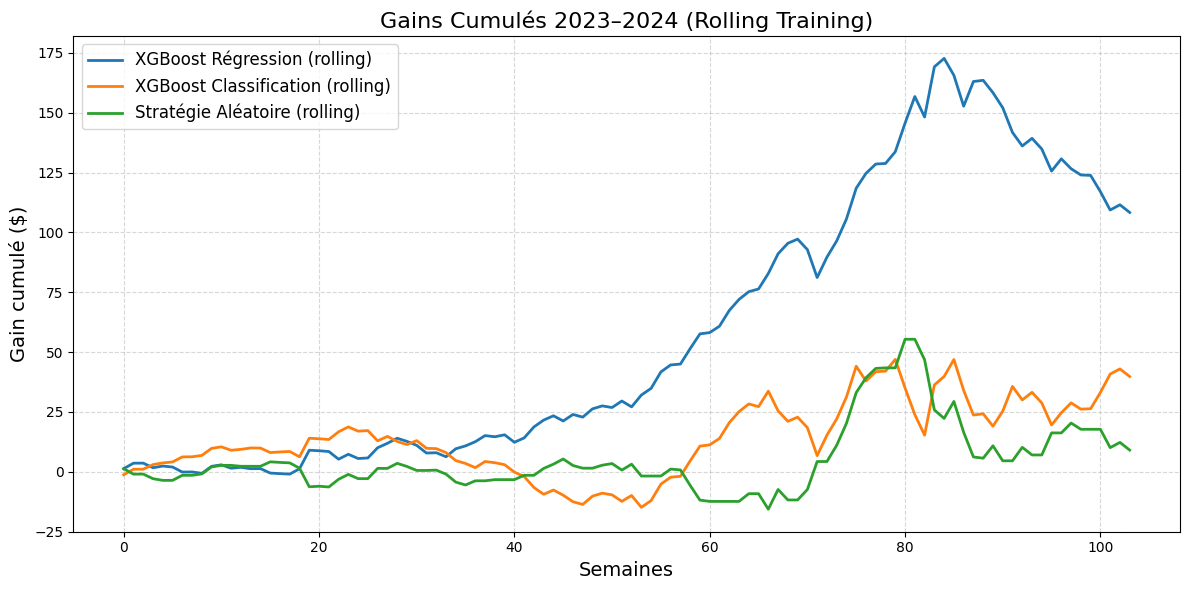

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# --- Construction des gains cumulés ---
cum_reg = np.cumsum(gains_reg_roll)
cum_clf = np.cumsum(gains_clf_roll)
cum_rand = np.cumsum(gains_rand_roll)

# --- Tracé du graphique ---
plt.figure(figsize=(12, 6))

plt.plot(cum_reg, label="XGBoost Régression (rolling)", linewidth=2)
plt.plot(cum_clf, label="XGBoost Classification (rolling)", linewidth=2)
plt.plot(cum_rand, label="Stratégie Aléatoire (rolling)", linewidth=2)

plt.title("Gains Cumulés 2023–2024 (Rolling Training)", fontsize=16)
plt.xlabel("Semaines", fontsize=14)
plt.ylabel("Gain cumulé ($)", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


## 16. Analyse des résultats

Les résultats montrent que :
- Les métriques ML (MAE, F1...) ne sont **pas directement corrélées** aux gains.
- XGBoost Régression dépasse les autres modèles en termes de performance économique.
- XGBoost Classification, après calibration, devient nettement plus robuste.
- Les modèles linéaires sont stables mais moins exploitables en trading.

Cela illustre un point fondamental :  
**un modèle peut être statistiquement moyen mais financièrement performant**  
s’il capture les bons mouvements.



## 17. Limites et perspectives

### Limites du projet

1. **Simplicité des features**
   Nous n’avons utilisé que des indicateurs techniques basés sur le prix 
   (moyennes mobiles, volatilité, variation).  
   Cela limite la capacité du modèle à capturer des dynamiques de marché complexes.
   Les modèles de ML peuvent apprendre davantage si l’on intègre :
   - des indicateurs de momentum plus avancés,
   - des signaux macroéconomiques,
   - ou des données fondamentales.

2. **Horizon unique (une semaine)**
   Le projet impose un horizon fixe de prédiction (t+1 semaine).
   Or certains comportements de marché sont mieux détectés sur :
   - des horizons journaliers,
   - ou mensuels,
   - ou multi-horizon (allocation dynamique).
   Cela limite la flexibilité du modèle.

3. **Modèles encore simples**
   Les modèles testés (régressions, XGBoost) restent relativement simples
   dans le contexte du trading algorithmique.  
   Nous n’avons pas exploré :
   - les réseaux neuronaux récurrents (LSTM/GRU),
   - les transformers temporels,
   - ou les régimes de volatilité.

4. **Absence de coûts de transaction**
   Le backtest ne prend pas en compte :
   - les commissions,
   - le slippage,
   - les spreads.
   Les performances réelles seraient légèrement inférieures.

5. **Pas de gestion du risque (risk management)**
   La stratégie ne considère pas :
   - la taille optimale des positions,
   - le drawdown maximal,
   - le risque systématique.  
   Le résultat final pourrait être amélioré via une allocation dynamique.

6. **Un seul actif étudié**
   Étudier uniquement NVDA limite la généralisation.
   Certains modèles pourraient mieux performer sur :
   - des indices,
   - des ETF,
   - des actions volatiles,
   - des actifs plus stationnaires.


### Perspectives d'amélioration

1. **Augmenter la richesse des features**
   Ajouter :
   - RSI, MACD, ROC, ADX  
   - ATR (volatilité)  
   - bandes de Bollinger  
   - signaux macro (VIX, taux, CPI)  
   - news sentiment (NLP)

2. **Optimiser la fenêtre d'entraînement**
   Au lieu d’utiliser “tout le passé disponible”, tester :
   - fenêtres glissantes de 1 an, 2 ans, 5 ans  
   Cela permet au modèle de s’adapter au régime de marché récent.

3. **Tester des modèles plus avancés**
   - LSTM/GRU (séquences longues)
   - Temporal Convolutional Networks (TCN)
   - Transformers temporels
   - CatBoost

4. **Intégrer un vrai système de décision**
   

5. **Tester sur plusieurs actifs**
   

6. **Vérifier la robustesse avec du walk-forward analysis**
   Approche encore plus stricte que notre backtest glissant.
